#Project Analysis: FedEx Logistic Performance Analysis
## Improving Delivery Timelines and Reducing Logistics Costs

####Project Type:EDA
####Contribution:Individual


# Business Problem Statement

The aim of this project is to analyze supply chain delivery data to identify factors causing delays and high freight costs and recommend strategies for improving logistics efficiency and customer satisfaction.



# Business Context

Supply chain and logistics operations play a critical role in ensuring timely product delivery and customer satisfaction.

Delayed shipments and increasing freight costs can negatively affect:
- operational efficiency
- customer trust
- inventory management
- transportation expenses

This project focuses on identifying operational bottlenecks and improving delivery performance through data-driven analysis.



# Dataset Column Description (Data Dictionary)

| Column Name | Description |
|---|---|
| ID | Unique identifier for each shipment record |
| Project Code | Code assigned to the project |
| PQ # | Purchase quotation number |
| PO / SO # | Purchase order or sales order number |
| ASN/DN # | Advance shipment notice or delivery note number |
| Country | Destination country of shipment |
| Managed By | Department or organization managing shipment |
| Fulfill Via | Shipment fulfillment method |
| Vendor INCO Term | International commercial shipping term |
| Shipment Mode | Transportation method such as Air or Sea |
| PQ First Sent to Client Date | Date when quotation was first sent |
| PO Sent to Vendor Date | Date when order was sent to vendor |
| Scheduled Delivery Date | Expected delivery date |
| Delivered to Client Date | Actual delivery date |
| Delivery Recorded Date | Date delivery was officially recorded |
| Product Group | Product category |
| Sub Classification | Sub-category of products |
| Vendor | Supplier or vendor name |
| Item Description | Description of shipped item |
| Molecule/Test Type | Medical or testing category |
| Brand | Product brand |
| Dosage | Product dosage details |
| Dosage Form | Form of medicine or product |
| Unit of Measure (Per Pack) | Quantity per pack |
| Line Item Quantity | Quantity shipped |
| Line Item Value | Monetary value of shipment |
| Pack Price | Price per pack |
| Unit Price | Price per unit |
| Manufacturing Site | Production location |
| First Line Designation | Priority designation |
| Weight (Kilograms) | Shipment weight |
| Freight Cost (USD) | Transportation cost |
| Line Item Insurance (USD) | Insurance amount for shipment |



# Hypothesis and Assumptions

The following assumptions were made during analysis:

1. Air shipment mode provides faster delivery but at higher cost.

2. Heavy shipments significantly increase freight expenses.

3. Certain vendors contribute more to delivery delays.

4. Some countries experience repeated delivery delays due to logistics challenges.

5. Higher delivery duration is associated with higher delay probability.

These hypotheses were tested using exploratory data analysis and visualization techniques.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

df = pd.read_csv('SCMS_Delivery_History_Dataset.csv')

print(df.shape)
df.head()


(10324, 33)


,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [ ]:

df.describe()


,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


# Missing Value Analysis

In [ ]:

missing = df.isnull().sum().sort_values(ascending=False)
print(missing)


Dosage                          1736
Shipment Mode                    360
Line Item Insurance (USD)        287
ID                                 0
Project Code                       0
Country                            0
Managed By                         0
PO / SO #                          0
PQ #                               0
Vendor INCO Term                   0
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Fulfill Via                        0
ASN/DN #                           0
Sub Classification                 0
Product Group                      0
Molecule/Test Type                 0
Vendor                             0
Brand                              0
Dosage Form                        0
Unit of Measure (Per Pack)         0
Item Description                   0
Line Item Quantity                 0
Line Item Value                    0
U

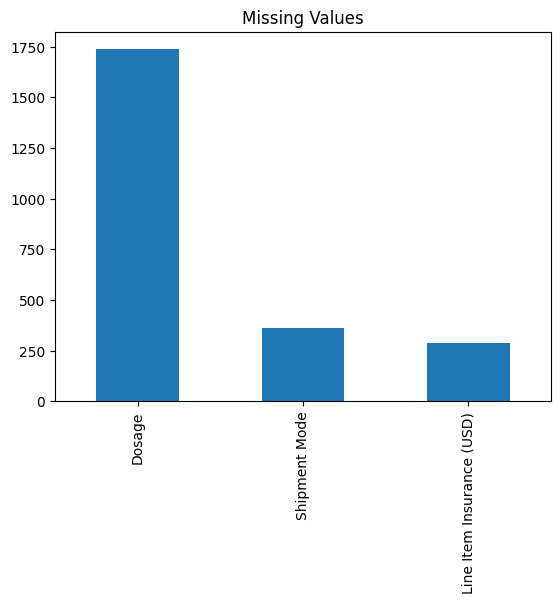

In [ ]:

missing[missing > 0].plot(kind='bar')
plt.title("Missing Values")
plt.show()


In [ ]:

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


# Feature Engineering

In [ ]:

date_cols = [
    'PQ First Sent to Client Date',
    'PO Sent to Vendor Date',
    'Scheduled Delivery Date',
    'Delivered to Client Date',
    'Delivery Recorded Date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')


/tmp/ipykernel_1053/137545135.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_1053/137545135.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_1053/137545135.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_1053/137545135.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent

In [ ]:
df['Delivery Delay Days'] = (
    df['Delivered to Client Date']
    - df['Scheduled Delivery Date']
).dt.days

df['Delivery Duration'] = (
    df['Delivered to Client Date']
    - df['PO Sent to Vendor Date']
).dt.days

df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')
df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

df['Cost Per Kg'] = (
    df['Freight Cost (USD)']
    / df['Weight (Kilograms)']
)

# Outlier Detection

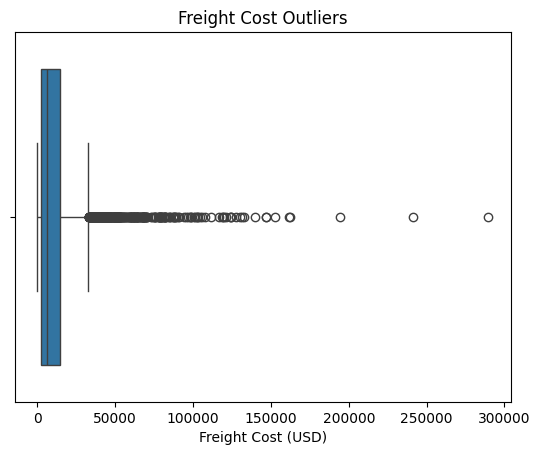

In [ ]:

sns.boxplot(x=df['Freight Cost (USD)'])
plt.title("Freight Cost Outliers")
plt.show()


# Shipment Mode vs Delivery Delay


### Insights Extracted
- Certain shipment modes experience higher delivery delays.
- Faster shipment methods reduce customer waiting time.
- Slower shipment modes may be more cost-efficient but affect customer satisfaction.


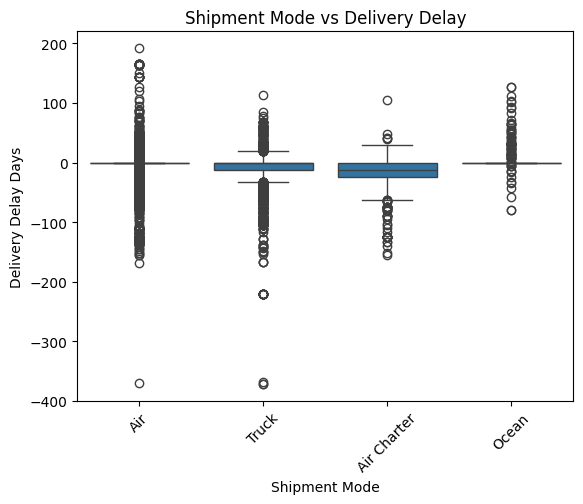

In [ ]:

sns.boxplot(
    data=df,
    x='Shipment Mode',
    y='Delivery Delay Days'
)

plt.xticks(rotation=45)
plt.title("Shipment Mode vs Delivery Delay")
plt.show()


# Shipment Mode vs Freight Cost


### Insights Extracted
- Air shipment generally shows higher freight costs.
- Some shipment modes balance both speed and cost effectively.
- Cost optimization can be achieved by selecting shipment modes strategically.


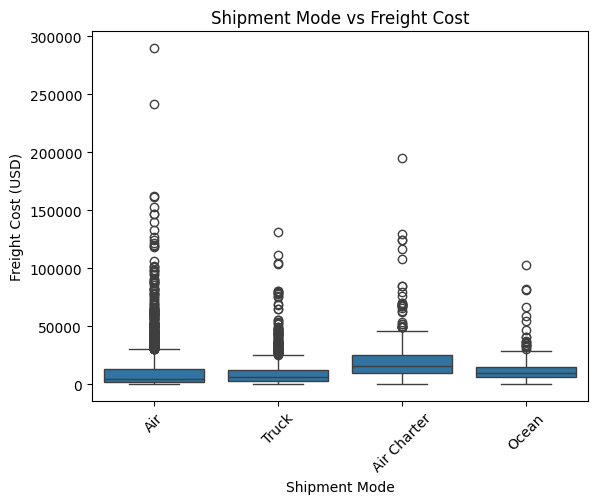

In [ ]:

sns.boxplot(
    data=df,
    x='Shipment Mode',
    y='Freight Cost (USD)'
)

plt.xticks(rotation=45)
plt.title("Shipment Mode vs Freight Cost")
plt.show()


# Country-wise Delay Analysis

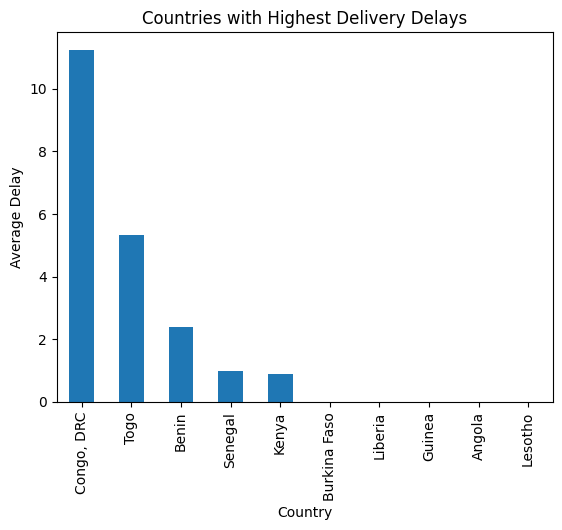

In [ ]:

country_delay = df.groupby('Country')['Delivery Delay Days'].mean() \
                  .sort_values(ascending=False).head(10)

country_delay.plot(kind='bar')

plt.title("Countries with Highest Delivery Delays")
plt.ylabel("Average Delay")
plt.show()


# Vendor Performance Analysis

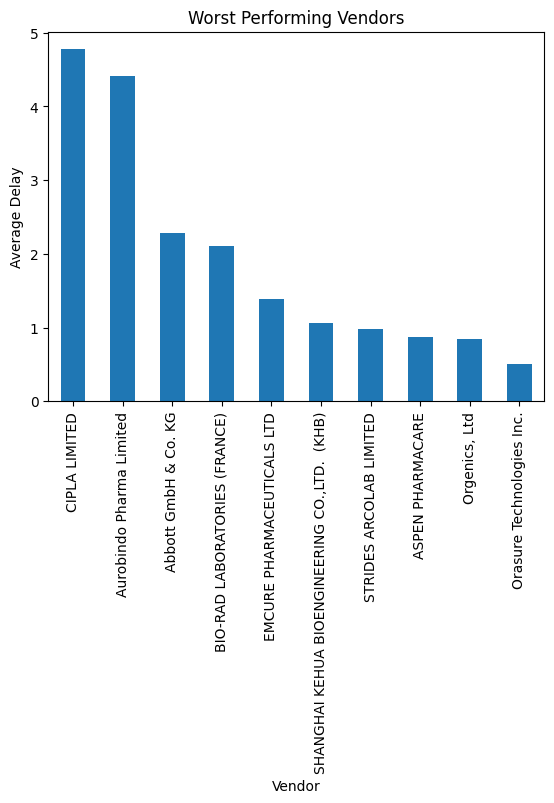

In [ ]:

vendor_delay = df.groupby('Vendor')['Delivery Delay Days'].mean() \
                 .sort_values(ascending=False).head(10)

vendor_delay.plot(kind='bar')

plt.title("Worst Performing Vendors")
plt.ylabel("Average Delay")
plt.show()


# Weight vs Freight Cost


### Insights Extracted
- Freight cost increases as shipment weight increases.
- Air transportation becomes significantly expensive for heavy shipments.
- Shipment consolidation can help reduce logistics expenses.


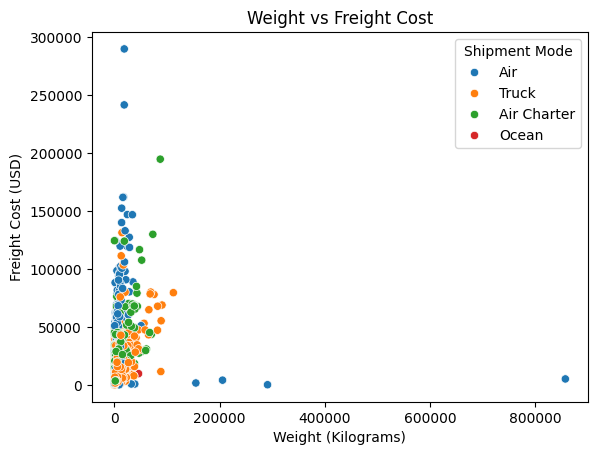

In [ ]:

sns.scatterplot(
    data=df,
    x='Weight (Kilograms)',
    y='Freight Cost (USD)',
    hue='Shipment Mode'
)

plt.title("Weight vs Freight Cost")
plt.show()


# Correlation Heatmap


### Insights Extracted
- Strong positive correlation exists between shipment weight and freight cost.
- Delivery duration is related to delivery delay.
- Correlation analysis helps identify operational factors affecting cost and efficiency.


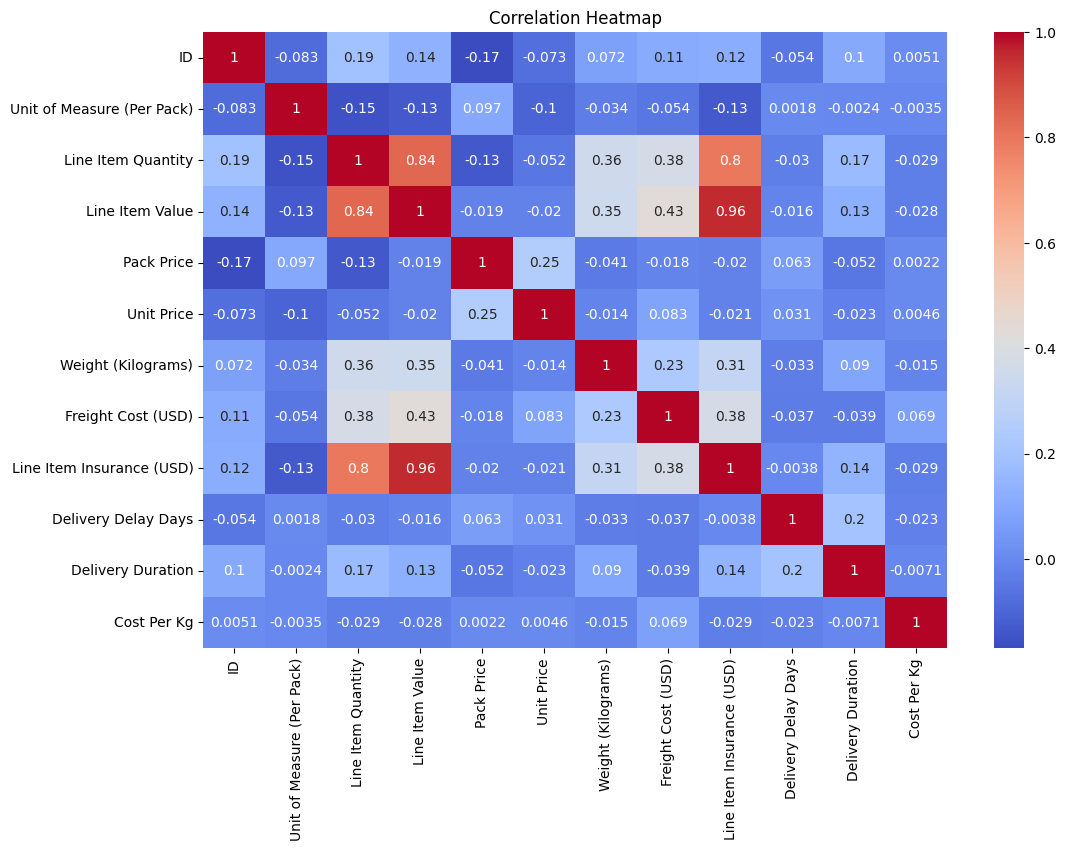

In [ ]:

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()



# Statistical Analysis

The following statistical analysis is performed to understand numerical relationships between important variables.


In [ ]:

df[['Freight Cost (USD)',
    'Weight (Kilograms)',
    'Delivery Delay Days']].describe()


,Freight Cost (USD),Weight (Kilograms),Delivery Delay Days
count,6198.000000,6372.000000,10324.000000
mean,11103.234819,3424.441306,-6.023537
std,15813.026692,13526.968270,27.233640
min,0.750000,0.000000,-372.000000
25%,2131.120000,206.750000,-3.000000
50%,5869.655000,1047.000000,0.000000
75%,14406.570000,3334.000000,0.000000
max,289653.200000,857354.000000,192.000000


In [ ]:

df[['Freight Cost (USD)',
    'Weight (Kilograms)',
    'Delivery Delay Days']].corr()


,Freight Cost (USD),Weight (Kilograms),Delivery Delay Days
Freight Cost (USD),1.000000,0.232052,-0.036779
Weight (Kilograms),0.232052,1.000000,-0.032824
Delivery Delay Days,-0.036779,-0.032824,1.000000



### Statistical Analysis Remarks

- Freight cost shows positive correlation with shipment weight.
- Delivery delays vary significantly across shipment modes.
- Large standard deviation in freight cost indicates presence of high-cost shipments.
- Correlation analysis helps identify operational factors affecting supply chain efficiency.


# KPI Metrics

In [ ]:

on_time = (df['Delivery Delay Days'] <= 0).sum()

total = len(df)

on_time_rate = (on_time / total) * 100

print("On-Time Delivery Rate:", round(on_time_rate,2), "%")


On-Time Delivery Rate: 88.51 %


# Final Recommendations


- Use air shipment only for urgent deliveries
- Monitor vendor performance using SLA systems
- Consolidate heavy shipments to reduce freight cost
- Improve warehouse and route planning
- Focus on countries with repeated delivery delays


# Conclusion


This project identified major factors affecting supply chain delivery performance and logistics cost. The analysis showed how shipment mode, vendor performance, shipment weight, and regional factors influence delays and operational expenses.

The insights generated from this project can help improve delivery timelines, reduce costs, and increase customer satisfaction.
